In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from csbdeep.utils import axes_dict, plot_some, plot_history
from csbdeep.utils.tf import limit_gpu_memory
from csbdeep.io import load_training_data
from csbdeep.models import Config, CARE

I0000 00:00:1764646421.833484   17587 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1764646422.369804   17587 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1764646424.177281   17587 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(X,Y), (X_val,Y_val), axes = load_training_data('./data/training_merged_wpermuted_20251111.npz', validation_split=0.1, verbose=True)

c = axes_dict(axes)['C'] 
n_channel_in, n_channel_out = X.shape[c], Y.shape[c]

number of training images:	 39558
number of validation images:	 4395
image size (3D):		 (96, 32, 32)
axes:				 SZYXC
channels in / out:		 1 / 1


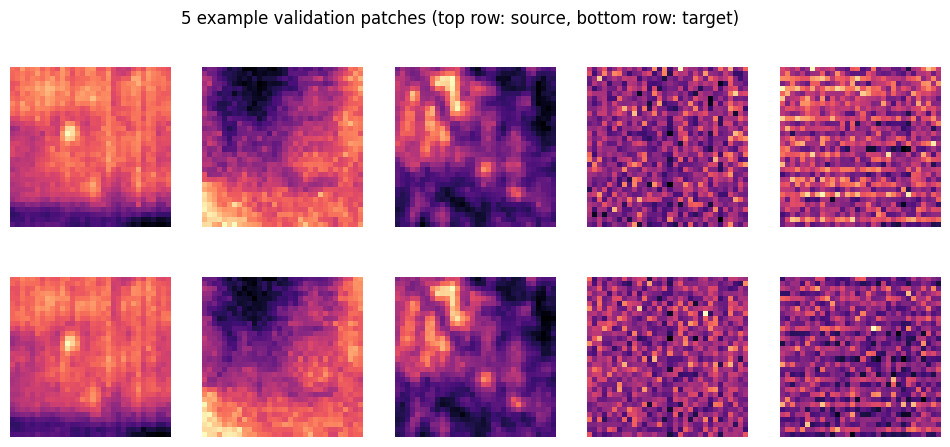

In [3]:
plt.figure(figsize=(12,5))
plot_some(X_val[:5],Y_val[:5])
plt.suptitle('5 example validation patches (top row: source, bottom row: target)');

In [4]:
config = Config(
    axes= axes,                # 3D with channel-last
    n_channel_in=1,
    n_channel_out=1,
    probabilistic=False,
    unet_residual=True,
    unet_n_depth=4,
    unet_kern_size=3,
    unet_n_first=32,
    train_epochs=100,
    train_steps_per_epoch=100,
)
print(config)
vars(config)

Config(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=1, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', probabilistic=False, unet_residual=True, unet_n_depth=4, unet_kern_size=3, unet_n_first=32, unet_last_activation='linear', unet_input_shape=(None, None, None, 1), train_loss='mae', train_epochs=100, train_steps_per_epoch=100, train_learning_rate=0.0004, train_batch_size=16, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 10, 'min_delta': 0})


{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 1,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'probabilistic': False,
 'unet_residual': True,
 'unet_n_depth': 4,
 'unet_kern_size': 3,
 'unet_n_first': 32,
 'unet_last_activation': 'linear',
 'unet_input_shape': (None, None, None, 1),
 'train_loss': 'mae',
 'train_epochs': 100,
 'train_steps_per_epoch': 100,
 'train_learning_rate': 0.0004,
 'train_batch_size': 16,
 'train_tensorboard': True,
 'train_reduce_lr': {'factor': 0.5, 'patience': 10, 'min_delta': 0}}

In [5]:
model = CARE(config, 'wpermute_model_4layers_20251111', basedir='models')

W0000 00:00:1764646666.270405   17587 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1764646666.274545   17587 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1764646666.491555   17587 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29041 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [6]:
history = model.train(X,Y, validation_data=(X_val,Y_val))

Epoch 1/100


I0000 00:00:1764646676.769736   19885 service.cc:158] XLA service 0x78b6e801f120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764646676.769768   19885 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1764646676.923312   19885 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764646677.513211   19885 cuda_dnn.cc:463] Loaded cuDNN version 91002
E0000 00:00:1764646684.958843   20100 slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[16,64,96,32,32]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,96,32,32]{4,3,2,1,0}, f32[32,64,3,3,3]{4,3,2,1,0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_r

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0288 - mae: 0.0288 - mse: 0.0015

/opt/venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 96, 32, 32, 1))',)
  warnings.warn(msg)


100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 399ms/step - loss: 0.0263 - mae: 0.0263 - mse: 0.0013 - val_loss: 0.0227 - val_mae: 0.0227 - val_mse: 9.3338e-04 - learning_rate: 4.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - loss: 0.0223 - mae: 0.0223 - mse: 9.0102e-04 - val_loss: 0.0219 - val_mae: 0.0219 - val_mse: 8.7034e-04 - learning_rate: 4.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - loss: 0.0220 - mae: 0.0220 - mse: 8.7113e-04 - val_loss: 0.0217 - val_mae: 0.0217 - val_mse: 8.5407e-04 - learning_rate: 4.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - loss: 0.0220 - mae: 0.0220 - mse: 8.7248e-04 - val_loss: 0.0217 - val_mae: 0.0217 - val_mse: 8.4696e-04 - learning_rate: 4.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0218 - mae: 0.0218 - mse: 8.5690e-04 - val_loss: 0.0216 - val_mae: 0.0216 - val_mse: 8.4240e-04 - learning_rate: 4.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


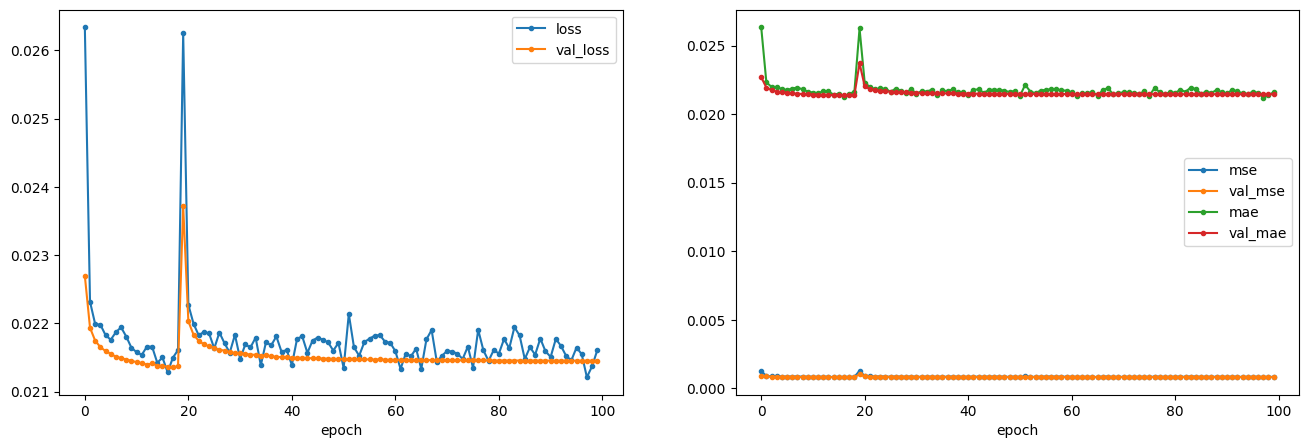

In [7]:
print(sorted(list(history.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [8]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(2e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 2e-4)

history2 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 340ms/step - loss: 0.0322 - mae: 0.0322 - mse: 0.0021 - val_loss: 0.0320 - val_mae: 0.0320 - val_mse: 0.0021 - learning_rate: 2.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: 0.0319 - mae: 0.0319 - mse: 0.0021 - val_loss: 0.0320 - val_mae: 0.0320 - val_mse: 0.0021 - learning_rate: 2.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0324 - mae: 0.0324 - mse: 0.0022 - val_loss: 0.0320 - val_mae: 0.0320 - val_mse: 0.0021 - learning_rate: 2.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - loss: 0.0321 - mae: 0.0321 - mse: 0.0021 - val_loss: 0.0320 - val_mae: 0.0320 - val_mse: 0.0021 - learning_rate: 2.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - loss: 0.0322 - mae: 0.0322 - mse: 0.0021 - val_loss: 0.0320 - val_mae: 0.0320 - val_mse: 0.0021 - learning_rate: 2.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: 0.0318 - mae: 0.0318 - mse

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


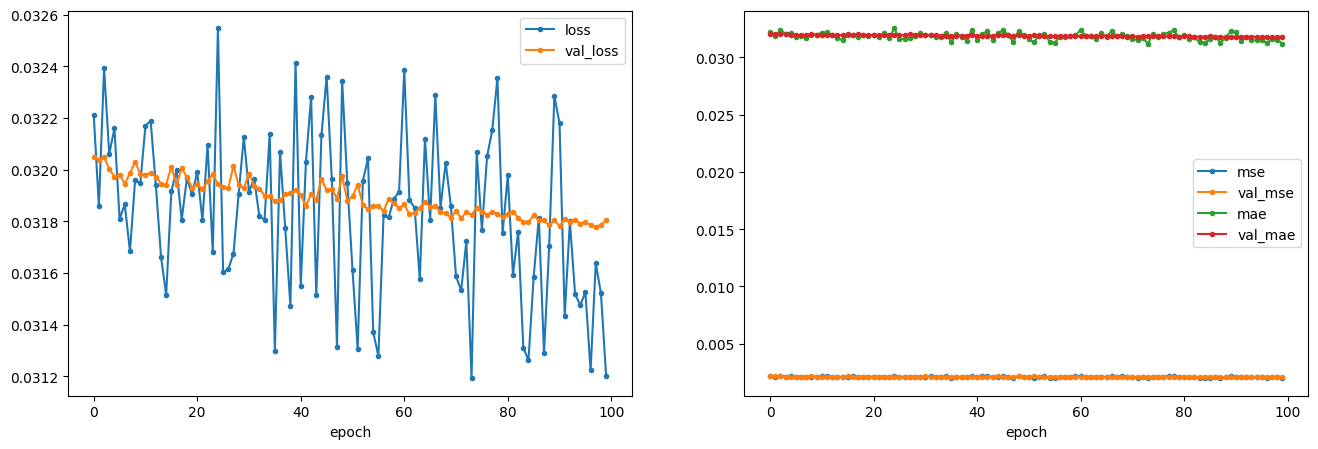

In [9]:
print(sorted(list(history2.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history2,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [10]:
history3 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - loss: 0.0317 - mae: 0.0317 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0319 - mae: 0.0319 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0314 - mae: 0.0314 - mse: 0.0020 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - loss: 0.0317 - mae: 0.0317 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0318 - mae: 0.0318 - mse: 0.0021 - val_loss: 0.0318 - val_mae: 0.0318 - val_mse: 0.0021 - learning_rate: 2.5000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - loss: 0.0315 - mae: 0.0315 - mse

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


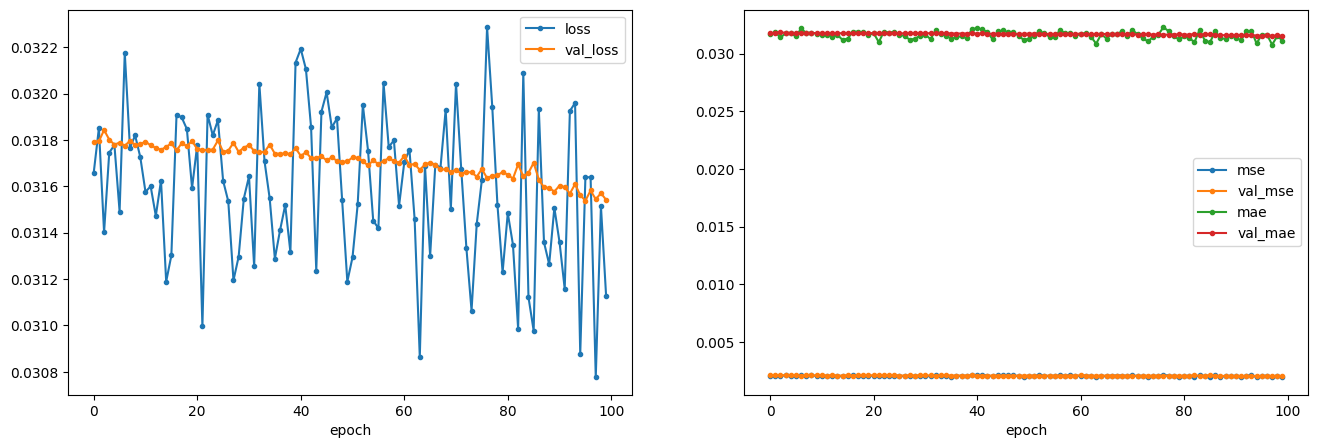

In [11]:
print(sorted(list(history3.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history3,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

In [16]:
import tensorflow as tf
opt = model.keras_model.optimizer

# Works in TF2.x
try:
    opt.learning_rate.assign(1e-4)
except AttributeError:
    # Older TF/Keras uses .lr
    tf.keras.backend.set_value(opt.lr, 1e-4)
history4 = model.train(X, Y, validation_data=(X_val, Y_val),
                       epochs=100, steps_per_epoch=100)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0414 - val_mae: 0.0414 - val_mse: 0.0033 - learning_rate: 1.0000e-04
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0403 - mae: 0.0403 - mse: 0.0030 - val_loss: 0.0413 - val_mae: 0.0413 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0402 - mae: 0.0402 - mse: 0.0030 - val_loss: 0.0412 - val_mae: 0.0412 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0401 - mae: 0.0401 - mse: 0.0029 - v

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


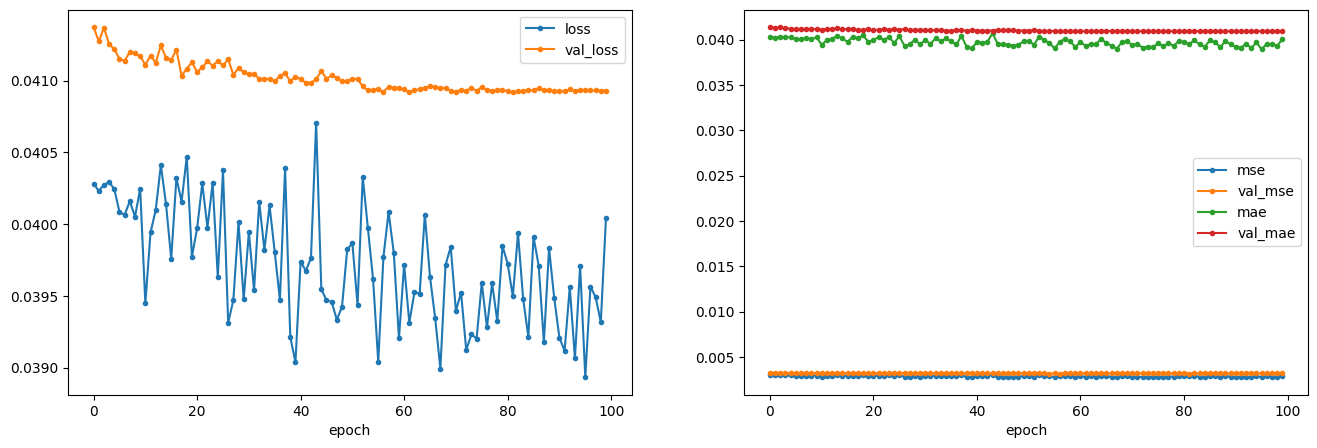

In [18]:
print(sorted(list(history4.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history4,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


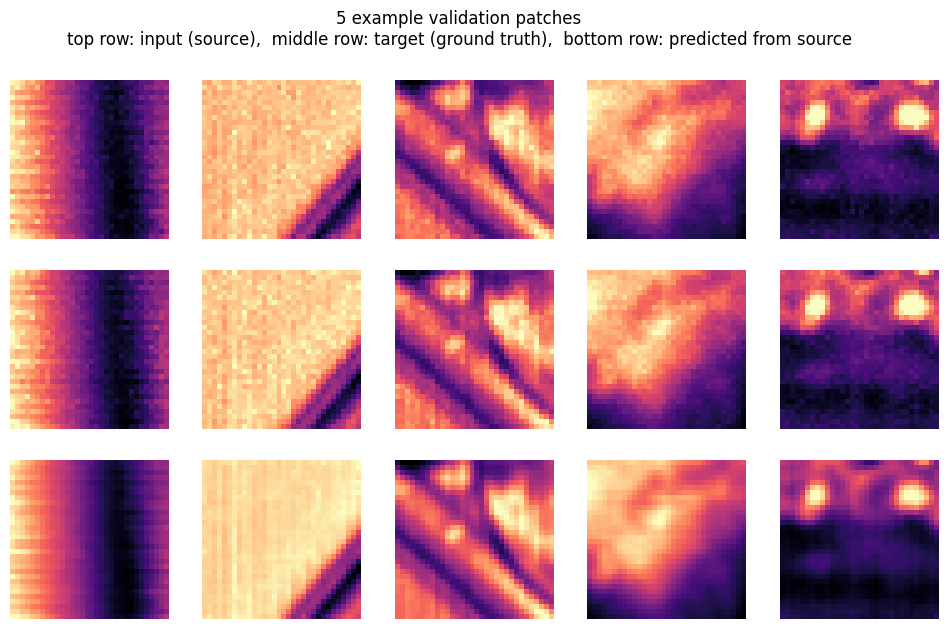

In [10]:
plt.figure(figsize=(12,7))
_P = model.keras_model.predict(X_val[5:10])
if config.probabilistic:
    _P = _P[...,:(_P.shape[-1]//2)]
plot_some(X_val[5:10],Y_val[5:10],_P,pmax=99.5)
plt.suptitle('5 example validation patches\n'      
             'top row: input (source),  '          
             'middle row: target (ground truth),  '
             'bottom row: predicted from source');

In [13]:
print(_P.shape)

(5, 96, 32, 32, 1)
